# Notebook 09 — IRASA vs specparam: method comparison (iEEG)

Compares aperiodic and oscillatory parameters estimated by **IRASA** (NB 08)
and **specparam** (NB 02) on the same 1772 iEEG channels (Frauscher 2018).

**Key questions**

1. How correlated are channel-level exponent / offset estimates?
2. Are regional rank orders preserved?
3. Do detected oscillatory peaks correspond in frequency?
4. Which channels show the largest discrepancy, and do they cluster by region?

**Important caveat on frequency ranges**:
- specparam (NB 02): fit on **2–100 Hz**
- IRASA (NB 08): fit on **2–40 Hz** (IRASA constraint: `band[1] * h_max < Nyquist`)

Both methods use the same Welch settings (2 s segments, 200 Hz).  Exponent
estimates are not trivially comparable across different fitting ranges (a wider
range will generally yield a lower exponent on 1/f spectra), so the Bland-Altman
plot in Section 1b explicitly documents this bias.

**Dependencies**: run NB 02 and NB 08 first to generate the interim CSVs.

**Outputs** saved to `data/interim/` and `manuscript/figures/`.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr

In [3]:
PROJECT_ROOT = Path("../../").resolve()
INTERIM_DIR  = PROJECT_ROOT / "data" / "interim"
FIG_DIR      = PROJECT_ROOT / "manuscript" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

R2_THRESHOLD = 0.80

LOBE_COLORS = {
    "Frontal":   "#E64B35",
    "Temporal":  "#4DBBD5",
    "Parietal":  "#00A087",
    "Occipital": "#3C5488",
    "Limbic":    "#F39B7F",
    "Insula":    "#8491B4",
    "Other":     "#91D1C2",
}

def lobe_color(lobe):
    return LOBE_COLORS.get(str(lobe), LOBE_COLORS["Other"])

## 0. Load results from both methods

In [4]:
sp_ch   = pd.read_csv(INTERIM_DIR / "specparam_ieeg_ch_summary.csv")
ir_ch   = pd.read_csv(INTERIM_DIR / "irasa_ieeg_ch_summary.csv")
sp_full = pd.read_csv(INTERIM_DIR / "specparam_ieeg_results.csv")
ir_full = pd.read_csv(INTERIM_DIR / "irasa_ieeg_results.csv")
sp_reg  = pd.read_csv(INTERIM_DIR / "region_aperiodic_ieeg.csv")
ir_reg  = pd.read_csv(INTERIM_DIR / "region_aperiodic_irasa_ieeg.csv")

print(f"specparam channels : {len(sp_ch)}")
print(f"IRASA channels     : {len(ir_ch)}")
print(f"specparam regions  : {len(sp_reg)}")
print(f"IRASA regions      : {len(ir_reg)}")

specparam channels : 1772
IRASA channels     : 1772
specparam regions  : 38
IRASA regions      : 38


## 1. Channel-level exponent and offset correlation

Restrict analysis to channels that pass QC in **both** methods (R² ≥ 0.80).

In [5]:
def report_corr(x, y, label):
    """Report Pearson and Spearman correlations, ignoring NaNs."""
    mask = ~(np.isnan(x) | np.isnan(y))
    r,   p_r  = pearsonr(x[mask],  y[mask])
    rho, p_s  = spearmanr(x[mask], y[mask])
    print(f"{label}: n={mask.sum()},  "
          f"Pearson r={r:.3f} (p={p_r:.3e}),  "
          f"Spearman ρ={rho:.3f} (p={p_s:.3e})")
    return r, p_r, rho, p_s

In [6]:
# Merge on channel ID; suffix _sp = specparam, _ir = IRASA
merged_ch = sp_ch[
    ["ID", "exponent", "offset", "gof_rsquared", "good_fit", "Region name", "Lobe"]
].merge(
    ir_ch[["ID", "exponent", "offset", "gof_rsquared", "good_fit"]],
    on="ID", suffixes=("_sp", "_ir")
)

both_good_mask = merged_ch["good_fit_sp"] & merged_ch["good_fit_ir"]
both_good = merged_ch[both_good_mask].copy()

print(f"Channels good in specparam only : {merged_ch['good_fit_sp'].sum() - both_good_mask.sum()}")
print(f"Channels good in IRASA only     : {merged_ch['good_fit_ir'].sum() - both_good_mask.sum()}")
print(f"Channels good in BOTH           : {both_good_mask.sum()} / {len(merged_ch)}")

both_good.to_csv(INTERIM_DIR / "irasa_vs_specparam_ch.csv", index=False)
print(f"Saved → {INTERIM_DIR / 'irasa_vs_specparam_ch.csv'}")

Channels good in specparam only : 272
Channels good in IRASA only     : 0
Channels good in BOTH           : 1500 / 1772
Saved → /Users/daniel/PhD/spectral-comparison/data/interim/irasa_vs_specparam_ch.csv


In [7]:
r_exp, p_exp, rho_exp, p_srho_exp = report_corr(
    both_good["exponent_sp"].values, both_good["exponent_ir"].values, "Exponent"
)
r_off, p_off, rho_off, p_srho_off = report_corr(
    both_good["offset_sp"].values, both_good["offset_ir"].values, "Offset"
)

Exponent: n=1500,  Pearson r=0.872 (p=0.000e+00),  Spearman ρ=0.865 (p=0.000e+00)
Offset: n=1500,  Pearson r=0.940 (p=0.000e+00),  Spearman ρ=0.939 (p=0.000e+00)


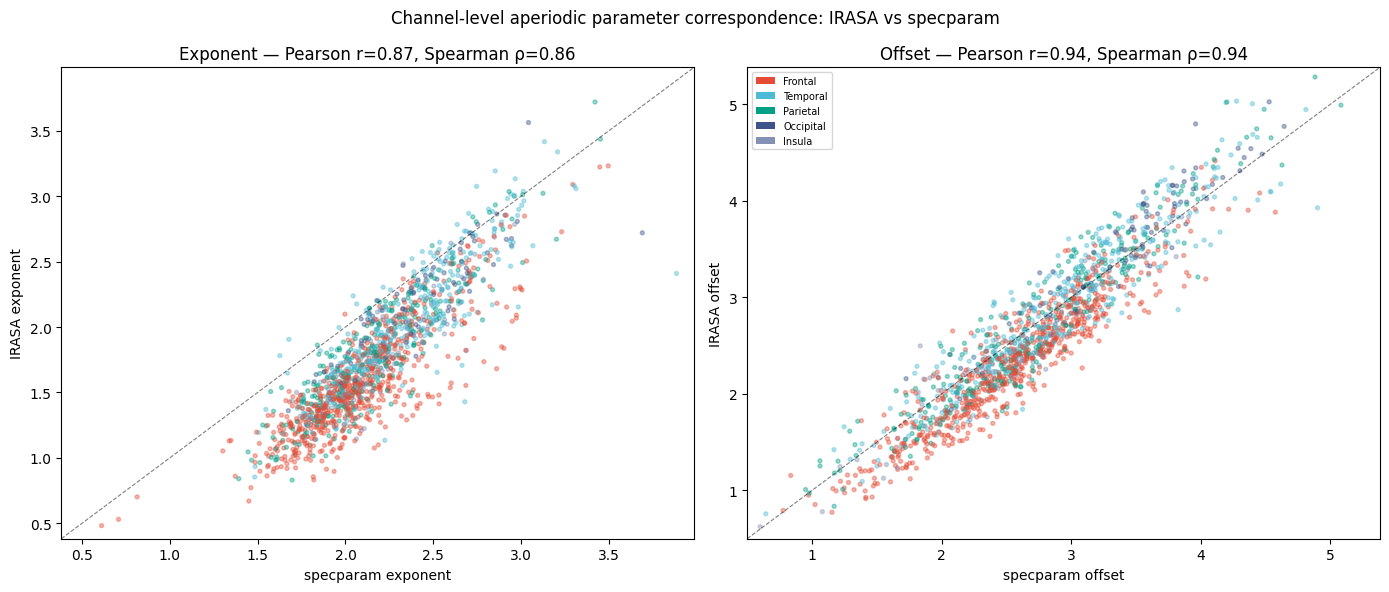

In [8]:
colors_ch = [lobe_color(l) for l in both_good["Lobe"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Exponent scatter ──────────────────────────────────────────────────────
ax = axes[0]
ax.scatter(both_good["exponent_sp"], both_good["exponent_ir"],
           c=colors_ch, s=8, alpha=0.4)
lims = [
    both_good[["exponent_sp", "exponent_ir"]].min().min() - 0.1,
    both_good[["exponent_sp", "exponent_ir"]].max().max() + 0.1,
]
ax.plot(lims, lims, "k--", alpha=0.5, linewidth=0.8)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("specparam exponent")
ax.set_ylabel("IRASA exponent")
ax.set_title(f"Exponent — Pearson r={r_exp:.2f}, Spearman ρ={rho_exp:.2f}")

# ── Offset scatter ────────────────────────────────────────────────────────
ax = axes[1]
ax.scatter(both_good["offset_sp"], both_good["offset_ir"],
           c=colors_ch, s=8, alpha=0.4)
lims_off = [
    both_good[["offset_sp", "offset_ir"]].min().min() - 0.1,
    both_good[["offset_sp", "offset_ir"]].max().max() + 0.1,
]
ax.plot(lims_off, lims_off, "k--", alpha=0.5, linewidth=0.8)
ax.set_xlim(lims_off); ax.set_ylim(lims_off)
ax.set_xlabel("specparam offset")
ax.set_ylabel("IRASA offset")
ax.set_title(f"Offset — Pearson r={r_off:.2f}, Spearman ρ={rho_off:.2f}")

# Lobe legend
legend_patches = [
    plt.Rectangle((0, 0), 1, 1, fc=c, label=lobe)
    for lobe, c in LOBE_COLORS.items()
    if lobe in both_good["Lobe"].values
]
axes[1].legend(handles=legend_patches, fontsize=7, loc="upper left")

fig.suptitle("Channel-level aperiodic parameter correspondence: IRASA vs specparam", fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_irasa_vs_specparam_channel.svg", bbox_inches="tight")
plt.show()

### 1b. Bland-Altman plot for exponent

Documents systematic bias between the two methods.  
IRASA typically yields **lower exponents** than specparam because its aperiodic
estimate is derived from the geometric mean of resampled spectra and is therefore
not affected by oscillatory peaks — whereas specparam's aperiodic fit can be
pulled upward by strong peaks if they overlap the fitting range.

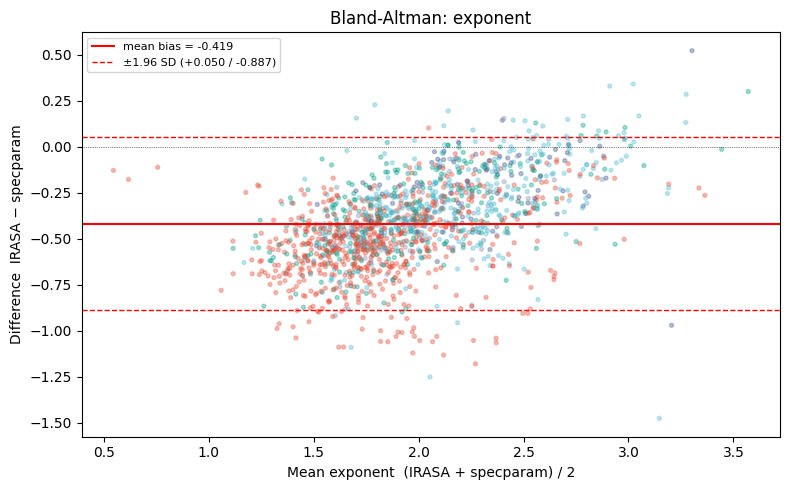

Mean bias (IRASA − specparam): -0.419  |  SD: 0.239


In [9]:
mean_exp = (both_good["exponent_sp"] + both_good["exponent_ir"]) / 2
diff_exp = both_good["exponent_ir"] - both_good["exponent_sp"]

bias = diff_exp.mean()
sd   = diff_exp.std()

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(mean_exp, diff_exp, c=colors_ch, s=8, alpha=0.35)
ax.axhline(bias,          color="red", linewidth=1.5,
           label=f"mean bias = {bias:+.3f}")
ax.axhline(bias + 1.96 * sd, color="red", linewidth=1, linestyle="--",
           label=f"±1.96 SD ({bias + 1.96*sd:+.3f} / {bias - 1.96*sd:+.3f})")
ax.axhline(bias - 1.96 * sd, color="red", linewidth=1, linestyle="--")
ax.axhline(0, color="black", linewidth=0.5, linestyle=":")
ax.set_xlabel("Mean exponent  (IRASA + specparam) / 2")
ax.set_ylabel("Difference  IRASA − specparam")
ax.set_title("Bland-Altman: exponent")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

print(f"Mean bias (IRASA − specparam): {bias:+.3f}  |  SD: {sd:.3f}")

## 2. Regional exponent correspondence

In [10]:
merged_reg = sp_reg[
    ["Region name", "Lobe", "exponent_median", "offset_median"]
].merge(
    ir_reg[["Region name", "exponent_median", "offset_median"]],
    on="Region name",
    suffixes=("_sp", "_ir")
).dropna(subset=["exponent_median_sp", "exponent_median_ir"])

print(f"Matched regions: {len(merged_reg)}")
merged_reg.to_csv(INTERIM_DIR / "irasa_vs_specparam_region.csv", index=False)

report_corr(
    merged_reg["exponent_median_sp"].values,
    merged_reg["exponent_median_ir"].values,
    "Regional exponent"
)
report_corr(
    merged_reg["offset_median_sp"].values,
    merged_reg["offset_median_ir"].values,
    "Regional offset"
)

Matched regions: 38
Regional exponent: n=38,  Pearson r=0.852 (p=1.133e-11),  Spearman ρ=0.828 (p=1.393e-10)
Regional offset: n=38,  Pearson r=0.918 (p=4.597e-16),  Spearman ρ=0.886 (p=1.339e-13)


(np.float64(0.9183617971687967),
 np.float64(4.597187473222317e-16),
 np.float64(0.8864208337892548),
 np.float64(1.3394870485419104e-13))

In [ ]:
colors_reg = [lobe_color(l) for l in merged_reg["Lobe"]]

rho_reg, _ = spearmanr(merged_reg["exponent_median_sp"], merged_reg["exponent_median_ir"])
r_reg,   _ = pearsonr(merged_reg["exponent_median_sp"],  merged_reg["exponent_median_ir"])

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(merged_reg["exponent_median_sp"], merged_reg["exponent_median_ir"],
           c=colors_reg, s=60, alpha=0.85, edgecolors="white", linewidths=0.5)

# Annotate 4 largest-discrepancy regions
residuals = (merged_reg["exponent_median_ir"] - merged_reg["exponent_median_sp"]).abs()
for i in residuals.nlargest(4).index:
    ax.annotate(
        merged_reg.loc[i, "Region name"],
        (merged_reg.loc[i, "exponent_median_sp"], merged_reg.loc[i, "exponent_median_ir"]),
        fontsize=7, xytext=(5, 4), textcoords="offset points"
    )

lims = [
    merged_reg[["exponent_median_sp", "exponent_median_ir"]].min().min() - 0.05,
    merged_reg[["exponent_median_sp", "exponent_median_ir"]].max().max() + 0.05,
]
ax.plot(lims, lims, "k--", alpha=0.5, linewidth=0.8)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("specparam exponent (regional median)")
ax.set_ylabel("IRASA exponent (regional median)")
ax.set_title(f"Regional exponent — Pearson r={r_reg:.2f}, Spearman ρ={rho_reg:.2f}")

legend_patches = [
    plt.Rectangle((0, 0), 1, 1, fc=c, label=lobe)
    for lobe, c in LOBE_COLORS.items()
    if lobe in merged_reg["Lobe"].values
]
ax.legend(handles=legend_patches, fontsize=8, loc="upper left")

fig.tight_layout()
fig.savefig(FIG_DIR / "fig_irasa_vs_specparam_regional.svg", bbox_inches="tight")
plt.show()

## 3. Oscillatory peak correspondence

For each channel that detected at least one peak in both methods, compare the
centre frequency of the **strongest** peak (by power / height).

In [11]:
def strongest_peak(df, id_col, cf_col, pw_col):
    """Return the highest-power peak per channel."""
    return (
        df.dropna(subset=[cf_col])
        .sort_values(pw_col, ascending=False)
        .drop_duplicates(subset=[id_col])[[id_col, cf_col, pw_col]]
    )


sp_peak1 = strongest_peak(sp_full, "ID", "CF", "PW").rename(
    columns={"CF": "CF_sp", "PW": "PW_sp"}
)
ir_peak1 = strongest_peak(ir_full, "ID", "cf", "pw").rename(
    columns={"cf": "cf_ir", "pw": "pw_ir"}
)

peaks_merged = (
    sp_peak1.merge(ir_peak1, on="ID")
    .merge(sp_ch[["ID", "Region name", "Lobe", "good_fit"]], on="ID")
)
peaks_merged = peaks_merged[peaks_merged["good_fit"]].copy()

rho_pk, p_pk = spearmanr(peaks_merged["CF_sp"], peaks_merged["cf_ir"])
print(f"Channels with dominant peak in both methods: {len(peaks_merged)}")
print(f"Peak CF Spearman ρ = {rho_pk:.3f}  (p = {p_pk:.3e})")

peaks_merged.to_csv(INTERIM_DIR / "irasa_vs_specparam_peaks.csv", index=False)

Channels with dominant peak in both methods: 1687
Peak CF Spearman ρ = -0.061  (p = 1.207e-02)


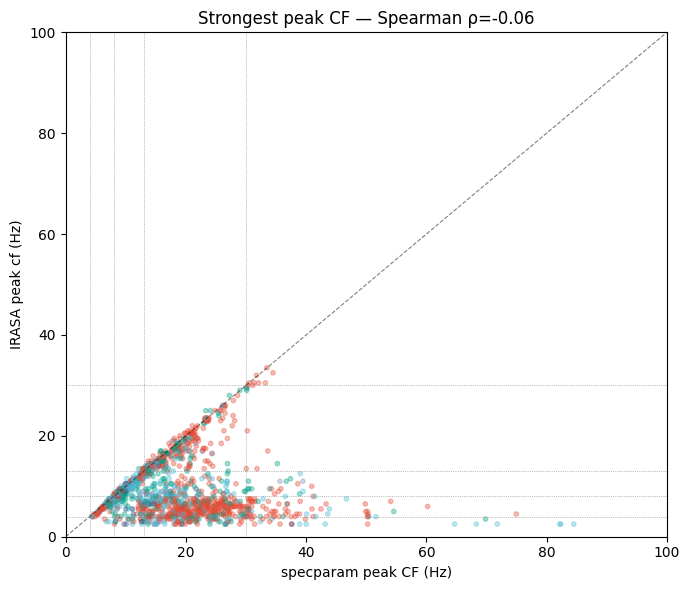

In [12]:
colors_pk = [lobe_color(l) for l in peaks_merged["Lobe"]]
band_bounds = [4, 8, 13, 30]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(peaks_merged["CF_sp"], peaks_merged["cf_ir"],
           c=colors_pk, s=10, alpha=0.35)
ax.plot([0, 100], [0, 100], "k--", alpha=0.5, linewidth=0.8)
for hz in band_bounds:
    ax.axvline(hz, color="grey", linewidth=0.5, linestyle=":")
    ax.axhline(hz, color="grey", linewidth=0.5, linestyle=":")
ax.set_xlim(0, 100); ax.set_ylim(0, 100)
ax.set_xlabel("specparam peak CF (Hz)")
ax.set_ylabel("IRASA peak cf (Hz)")
ax.set_title(f"Strongest peak CF — Spearman ρ={rho_pk:.2f}")
fig.tight_layout()
plt.show()

## 4. Channels with the largest exponent discrepancy

In [13]:
both_good["exponent_diff"]     = both_good["exponent_ir"] - both_good["exponent_sp"]
both_good["exponent_diff_abs"] = both_good["exponent_diff"].abs()

print("Top-10 channels by |IRASA exponent − specparam exponent|:")
display_cols = [
    "ID", "Region name", "Lobe",
    "exponent_sp", "exponent_ir", "exponent_diff",
    "gof_rsquared_sp", "gof_rsquared_ir",
]
top10 = both_good.nlargest(10, "exponent_diff_abs")[display_cols].round(3)
print(top10.to_string(index=False))

Top-10 channels by |IRASA exponent − specparam exponent|:
 ID                              Region name     Lobe  exponent_sp  exponent_ir  exponent_diff  gof_rsquared_sp  gof_rsquared_ir
576                    Middle temporal gyrus Temporal        3.885        2.409         -1.476            0.990            0.874
472                                 Amygdala Temporal        2.680        1.429         -1.251            0.981            0.944
975  Superior frontal gyrus and frontal pole  Frontal        2.861        1.681         -1.180            0.980            0.830
221  Superior frontal gyrus and frontal pole  Frontal        2.685        1.553         -1.132            0.983            0.801
218                         Precentral gyrus  Frontal        2.533        1.413         -1.121            0.953            0.884
471                                 Amygdala Temporal        2.224        1.134         -1.090            0.970            0.894
216                         Precentral 

In [16]:
print("Mean exponent difference (IRASA − specparam) by lobe:")
lobe_disc = (
    both_good.groupby("Lobe")["exponent_diff"]
    .agg(["mean", "std", "count"])
    .round(3)
    .sort_values("mean")
)
print(lobe_disc.to_string())

Mean exponent difference (IRASA − specparam) by lobe:
            mean    std  count
Lobe                          
Frontal   -0.520  0.216    667
Insula    -0.425  0.197     89
Parietal  -0.369  0.215    285
Temporal  -0.318  0.233    373
Occipital -0.225  0.198     86


## 5. Summary table

In [17]:
summary = pd.DataFrame({
    "Metric": ["Exponent", "Offset", "Peak CF (dominant)", "Regional exponent"],
    "Pearson r": [
        round(r_exp, 3),
        round(r_off, 3),
        None,
        round(r_reg, 3),
    ],
    "Spearman ρ": [
        round(rho_exp, 3),
        round(rho_off, 3),
        round(rho_pk, 3),
        round(rho_reg, 3),
    ],
    "N": [
        len(both_good),
        len(both_good),
        len(peaks_merged),
        len(merged_reg),
    ],
    "Note": [
        f"R²≥{R2_THRESHOLD} in both methods",
        f"R²≥{R2_THRESHOLD} in both methods",
        "Channels with ≥1 peak in both methods",
        "Matched AAL regions",
    ],
})
print(summary.to_string(index=False))
summary.to_csv(INTERIM_DIR / "irasa_vs_specparam_summary.csv", index=False)

NameError: name 'r_reg' is not defined